Food Demand System Estimation
-

This project estimates a food demand system using household expenditure and demographic data. The goal is to understand how spending differs across food categories and how consumption changes with household need, including household size, age structure, and gender composition.

Project Overview: 
- $\mathbf{Data}$: Household food expenditure and demographic characteristics
- $\mathbf{Method}$: Demand system estimation using log expenditures
- $\mathbf{Goal}$: Study how food demand varies with income and household composition

In [14]:
#%pip install -r requirements-estimation.txt

In [15]:
#%pip install -r requirements.txt -q

In [9]:
from eep153_tools.sheets import read_sheets

# Data


$\textbf{Population of Interest}$: Nigeria

We will be using the following spreadsheet for our data: https://docs.google.com/spreadsheets/d/1rbWPdn_Rt3MRoFb_wkomHBcNVmM-3F3lNwCpxP5W_3g/edit?gid=1354121303#gid=1354121303


In [10]:
NG_URL= "https://docs.google.com/spreadsheets/d/1rbWPdn_Rt3MRoFb_wkomHBcNVmM-3F3lNwCpxP5W_3g/edit?gid=1354121303#gid=1354121303" 

In [11]:
import pandas as pd
import numpy as np

FE_Sheets = ["Food Expenditures (2010Q3)", "Food Expenditures (2011Q1)", "Food Expenditures (2012Q3)", "Food Expenditures (2013Q1)", "Food Expenditures (2015Q3)", "Food Expenditures (2016Q1)"]

FP_Sheets = ["Food Prices (2010Q3)", "Food Prices (2011Q1)", "Food Prices (2012Q3)", "Food Prices (2013Q1)", "Food Prices (2015Q3)", "Food Prices (2016Q1)"]

def prepare_data(NG_URL, FE_Sheet, household_sheet="Household Characteristics"): 
    x = read_sheets(NG_URL, sheet = FE_Sheet)
    d = read_sheets(NG_URL ,sheet = household_sheet)

    # data cleaning to ensure key columns match exactly
    for df in [x, d]:
        df['i'] = pd.to_numeric(df['i'], errors='coerce')
        df['t'] = df['t'].astype(str).str.strip()
        df['m'] = (
            df['m']
            .astype(str)
            .str.strip()
            .str.lower()
            .str.replace(r'\s+', ' ', regex=True)
        )


    d.columns.name = 'k'
    # remove duplicate column names, keep first occurrence
    d = d.loc[:, ~d.columns.duplicated()]

    # collapse duplicate household rows
    d = d.groupby(['i','t','m'], as_index=False).first()

    # Data comes in long format; pivot to wide (one column per food)
    x = x.pivot_table(index=['i','t','m'],columns='j',values='Expenditure',
                   aggfunc='sum')
    x = x.replace(0,np.nan) # Replace zeros with missing

    # Take logs of expenditures; call this y
    y = np.log(x)

    d.set_index(['i','t','m'],inplace=True)

    # NaN in demographic columns means zero people in that category
    d = d.fillna(0)

    return y, d

In [12]:
#We are only doing one year & quarter for now, but we can incorporate the other sheets later on to get a holistic undestanding
y, d = prepare_data(NG_URL, "Food Expenditures (2010Q3)")

In [16]:
d.head()

k                        Female 00-03  Female 04-08  Female 09-13  \
i     t      m                                                      
10001 2010Q3 south east             1             0             0   
      2011Q1 south east             1             0             0   
      2012Q3 south east             1             0             0   
      2013Q1 south east             0             1             0   
      2015Q3 south east             0             1             0   

k                        Female 14-18  Female 19-30  Female 31-50  Female 51+  \
i     t      m                                                                  
10001 2010Q3 south east             0             1             2           0   
      2011Q1 south east             0             1             2           0   
      2012Q3 south east             0             1             2           0   
      2013Q1 south east             0             1             2           0   
      2015Q3 south east             0             0             2           0   

k                        Female NA  Male 00-03  Male 04-08  Male 09-13  \
i     t      m                                                           
10001 2010Q3 south east          0           0           0           0   
      2011Q1 south east          0           0           0           0   
      2012Q3 south east          0           0           0           0   
      2013Q1 south east          0           1           0           0   
      2015Q3 south east          1           1           0           0   

k                        Male 14-18  Male 19-30  Male 31-50  Male 51+  \
i     t      m                                                          
10001 2010Q3 south east           0           1           2         0   
      2011Q1 south east           0           1           2         0   
      2012Q3 south east           0           0           1         2   
      2013Q1 south east           0           0           1         2   
      2015Q3 south east           0           0           0         1   

k                        Male NA  log HSize  
i     t      m                               
10001 2010Q3 south east        0   1.945910  
      2011Q1 south east        0   1.945910  
      2012Q3 south east        0   1.945910  
      2013Q1 south east        0   2.079442  
      2015Q3 south east        2   2.079442

In [17]:
y.head()

,,j,Avocado pear,Baby milk powder,Bananas,Beef,Beer,Bottled water,Bread,Brown beans,Butter/Margarine,Canned beef/corned beef,...,Sugar,Sweet potatoes,Tea,Tomato puree (canned),Tomatoes,Wheat flour,White beans,Wild game meat,Yam flour,Yam--roots
i,t,m,,,,,,,,,,,,,,,,,,,,,
10001,2010Q3,south east,NaN,NaN,4.892852,6.214608,5.075174,5.247024,5.886104,6.396930,NaN,NaN,...,NaN,NaN,NaN,4.787492,4.605170,NaN,5.703782,NaN,NaN,6.684612
10002,2010Q3,south east,NaN,NaN,4.759321,NaN,7.377759,7.038784,5.886104,4.787492,NaN,NaN,...,3.757872,NaN,3.401197,3.401197,4.382027,6.44572,5.347108,NaN,NaN,5.991465
10003,2010Q3,south east,NaN,NaN,4.605170,6.214608,NaN,NaN,5.480639,NaN,NaN,NaN,...,5.837314,NaN,NaN,5.192957,4.199705,NaN,5.347108,NaN,NaN,5.991465
10004,2010Q3,south east,NaN,NaN,2.813411,6.214608,NaN,4.553877,5.480639,5.347108,NaN,NaN,...,3.757872,NaN,NaN,4.499810,4.199705,NaN,NaN,NaN,NaN,NaN
10005,2010Q3,south east,NaN,NaN,NaN,7.025538,NaN,NaN,6.733402,5.010635,5.298317,NaN,...,3.940194,NaN,3.401197,5.010635,NaN,NaN,5.703782,NaN,NaN,6.396930


Estimation 
-


Let $y_i^j$ be log expendicture on food $j$ by household $i$ at a particular time. We want to estimate a regression that takes the form: 

$y_i^j = A^j(p) + \gamma_j' d_i + \beta_j w_i + \zeta_i^j$
-



In [18]:
y = y.stack().dropna()

d = d.stack().dropna()

# Check that indices are in right places!
assert y.index.names == ['i','t','m','j']
assert d.index.names == ['i','t','m','k']

Basic Estimation
-

In [19]:
from cfe import Regression

result = Regression(y=y,d=d)

In [20]:
result.predicted_expenditures()

i       t       m              j                    
10001   2010Q3  south east     Bananas                  212.988051
                               Beef                     741.340838
                               Bread                    400.456010
                               Brown beans              321.362014
                               Cassava (root)           319.982447
                                                           ...    
370040  2010Q3  north central  Tea                      314.046173
                               Tomato puree (canned)    326.283595
                               Tomatoes                 213.843532
                               White beans              527.265765
                               Yam--roots               800.469253
Length: 187380, dtype: float64

<Axes: xlabel='yhat', ylabel='y'>

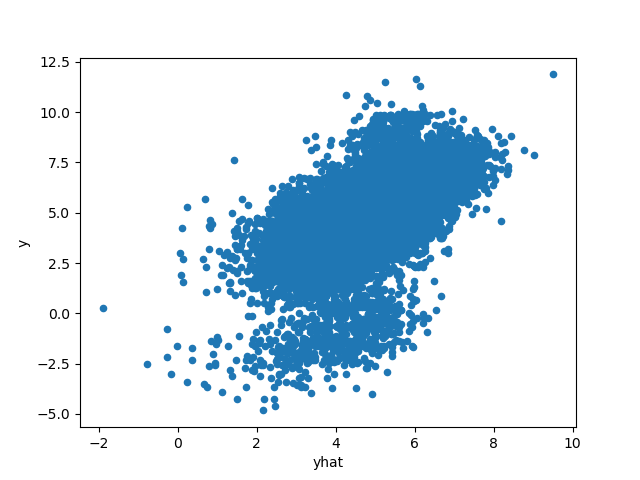

In [21]:
%matplotlib widget
df = pd.DataFrame({'y':y,'yhat':result.get_predicted_log_expenditures()})
df.plot.scatter(x='yhat',y='y')

Interpretation of Results
-

The table tells us what the model predicts households will spend, and the plot tells us how close those predictions are to actual spending

# Parameters: 


(Relative) Income Elasticity:
-


 
$\beta$ coefficients govern how income elastic different goods are (higher values means more elastic). These are also called Frisch elasticities

In [22]:
result.get_beta().sort_values()

j
Malt drinks                            -0.194099
Soft drinks (Coca Cola, spirit, etc)    0.161318
Plantains                               0.286383
Yam--roots                              0.289269
Milk powder                             0.290013
Chicken                                 0.300635
Condiments                              0.328707
Tea                                     0.338059
Sachet water                            0.345818
Palm oil                                0.384663
Chocolate drinks                        0.409257
Milk tinned (unsweetened)               0.413226
Tomato puree (canned)                   0.446843
Fish--frozen                            0.496065
Eggs                                    0.516191
Orange/tangerine                        0.583674
Bread                                   0.597486
Groundnut oil                           0.606028
Beef                                    0.632846
Goat                                    0.713641
Fish--dried       

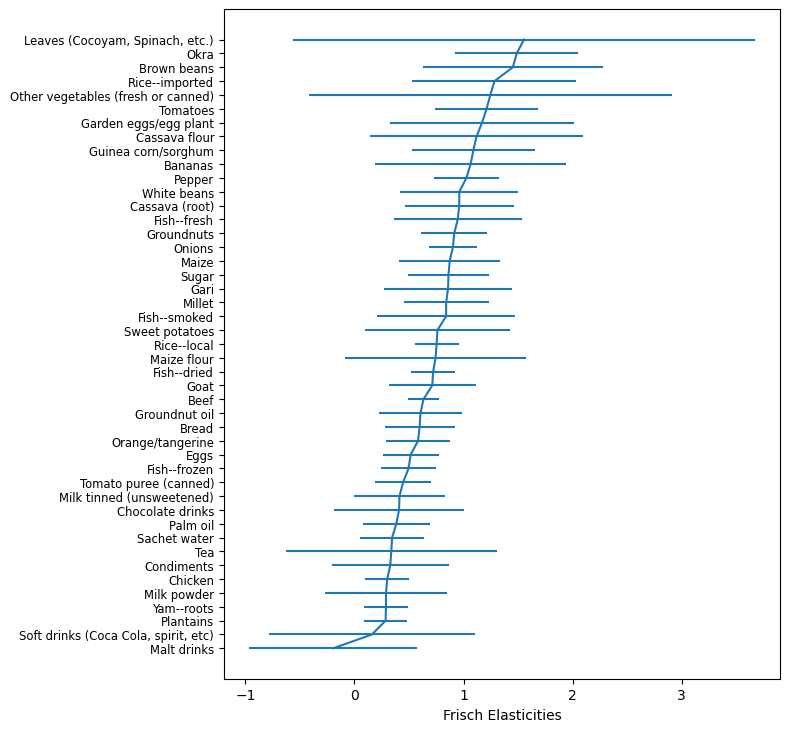

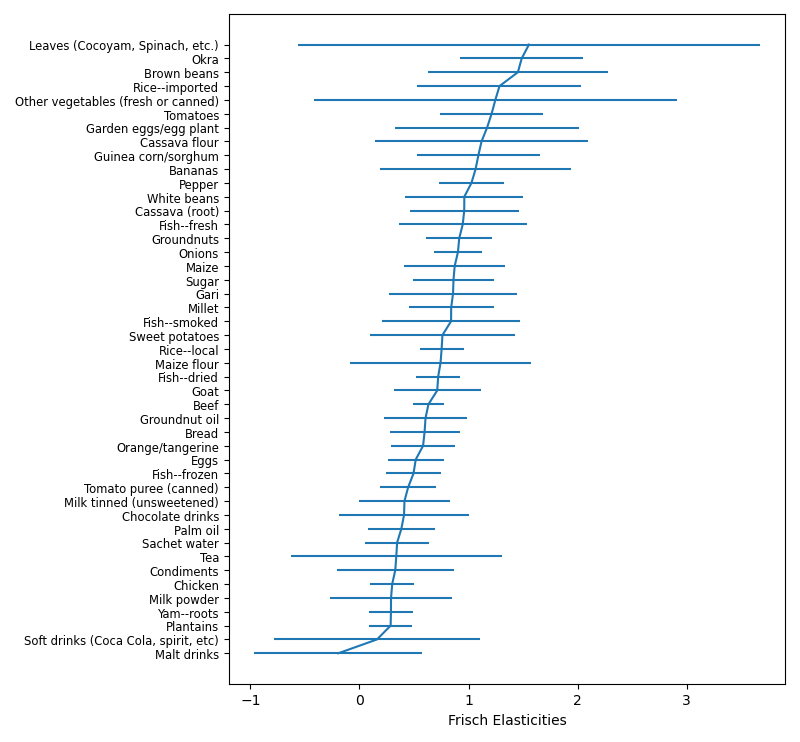

In [23]:
result.graph_beta()

Interpretation of $\beta$ values 
-

Goods with higher $\beta$ values are more responsive to income, while goods with lower $\beta$ values are less responsive. This means that when a household has more resources to spend, it tends to increase spending more on goods with higher 

Some specific examples from above:
- Onions ($\beta$ ≈0.90) and groundnuts ($\beta$ ≈0.91) look relatively income-elastic, meaning spending on these tends to rise more as household resources rise
- Tea ($\beta$ ≈0.34) and condiments ($\beta$ ≈0.33) look less income-responsive, meaning households do not change spending on them as much when resources change
- Malt drinks ($\beta$ ≈−0.19) is especially interesting because the negative value suggests spending on malt drinks tends to fall, relative to other goods, as household resources increase

# Demand and Household Composition

$\gamma_{j}$ parameters in the regression are the effects of household composition on demand.

In [24]:
result.gamma

k,Female 00-03,Female 04-08,Female 09-13,Female 14-18,Female 19-30,Female 31-50,Female 51+,Female NA,Male 00-03,Male 04-08,Male 09-13,Male 14-18,Male 19-30,Male 31-50,Male 51+,Male NA,log HSize,Constant
j,,,,,,,,,,,,,,,,,,
Bananas,-0.042729,-0.006260,0.059784,-0.054557,0.044347,0.065558,0.056149,0.391099,-0.024085,0.006661,-0.038008,-0.094150,0.052004,0.068614,-0.033623,-0.833479,0.517954,4.845551
Beef,-0.094510,-0.097349,-0.030770,-0.121996,-0.004656,-0.017675,-0.114499,0.274669,-0.006820,-0.037340,-0.016446,-0.054093,-0.030780,-0.020267,0.034163,0.172027,0.742792,6.324994
Bread,-0.178036,-0.130658,0.013538,-0.100075,-0.058628,-0.021317,0.083944,-0.505041,-0.093005,-0.112407,-0.026208,-0.087310,-0.030919,-0.031677,-0.093679,0.097821,0.818240,5.232184
Brown beans,-0.217328,-0.020960,-0.169415,-0.026783,-0.010593,-0.122806,-0.086636,0.370872,-0.171730,-0.080806,-0.085803,0.058041,0.000697,0.104621,0.177214,0.440517,1.088305,5.309179
Cassava (root),-0.095963,-0.179125,0.084105,0.050644,-0.031099,-0.128921,0.005367,0.211398,-0.205980,-0.055368,-0.147220,-0.030228,-0.135352,-0.373030,-0.165623,-0.014669,0.730628,5.552863
Cassava flour,-0.098736,-0.043772,0.148016,0.052015,0.035675,-0.150760,0.218295,-0.307521,-0.193696,-0.043561,0.061552,-0.060627,0.073415,0.139655,0.171765,-1.128673,0.778912,5.473425
Chicken,-0.119930,-0.063007,-0.069326,-0.231890,-0.051673,-0.068299,-0.236890,-0.202406,-0.070063,-0.073590,-0.052680,-0.142425,-0.019479,0.010727,0.007457,0.179863,0.878910,6.568785
Chocolate drinks,-0.199011,-0.058665,0.003849,-0.215472,-0.214046,-0.423548,-0.201058,0.080957,-0.206879,-0.060522,-0.081322,-0.198657,-0.131032,-0.049284,-0.106686,-1.275575,1.194087,5.318591
Condiments,-0.038719,-0.033897,-0.005510,0.028183,-0.067945,-0.126978,-0.119387,0.400133,0.116140,0.004002,0.003425,-0.002040,-0.036199,0.012891,0.037645,-0.085225,0.624319,3.471433


Interpretation of $\gamma$ values
-

The $\gamma$ coefficients show how household composition affects demand for each food. A positive $\gamma$ means that households with more people in that demographic category tend to spend more on that good, while a negative $\gamma$ means they tend to spend less. In simple terms, these values tell us how food demand changes depending on who lives in the household.

Some specfic values from above: 
- Bananas: the coefficient on Female 31–50 is positive ($\gamma$≈0.066), while the coefficient on Male 14–18 is negative ($\gamma$≈−0.094). This suggests banana spending tends to be higher in households with more adult women ages 31 to 50, but lower in households with more males ages 14 to 18.
- Cassava (root): the coefficient on Female 09–13 is positive ($\gamma$≈0.084), while the coefficients on Male 00–03 and Male 31–50 are negative ($\gamma$≈−0.206 and $\gamma$≈−0.373). This suggests cassava root spending tends to be higher in households with more girls ages 9 to 13, but lower in households with more very young boys or adult men ages 31 to 50.

Created by: Natalie Cornejo, Inaaya Hasham, Kita Hu, Benjamin Zacharia, & Tanaisha Mistry